# Import các thư viện cần thiết

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Đọc dữ liệu `data/train.csv`

In [5]:
DATA_PATH = '../data/'
df = pd.read_csv(DATA_PATH + 'train.csv', index_col='id')

print('Dataframe shape: ', df.shape)
df.head()

Dataframe shape:  (140700, 19)


,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
id,,,,,,,,,,,,,,,,,,,
0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Yuvraj,Male,33.0,Visakhapatnam,Student,NaN,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


# Missing values

In [12]:
df_missing = df.isna().sum()
df_missing


Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64

# Unique values trong các cột phân loại

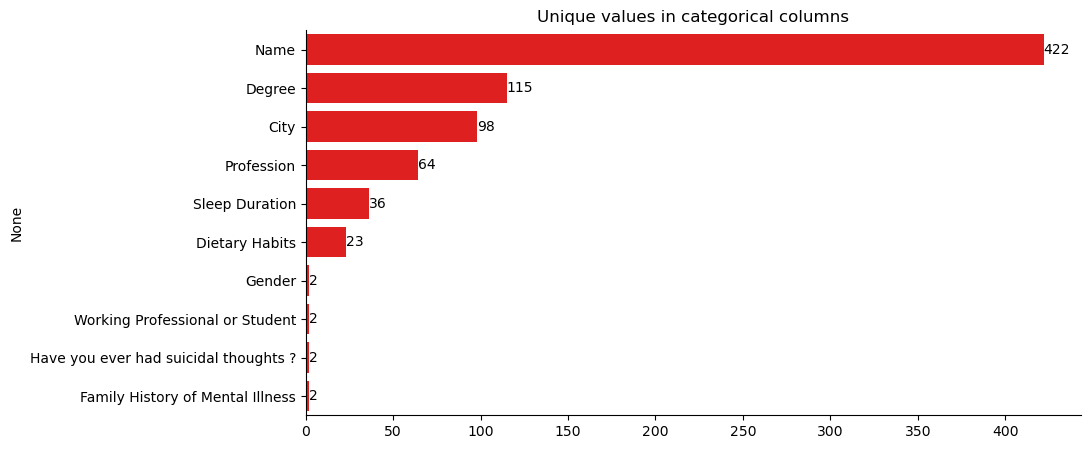

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.barplot(
    x = df[cat_cols].nunique().sort_values(ascending=False).values,
    y = df[cat_cols].nunique().sort_values(ascending=False).index,
    ax = ax,
    color = "red"
)
ax.set_title('Unique values in categorical columns')

for i, value in enumerate(df[cat_cols].nunique().sort_values(ascending=False).values):
    ax.text(value, i, f'{value}', va='center')

sns.despine()
plt.show()

# Preprocessing

In [15]:
missing_cols = df_missing[df_missing > 0].index.tolist()
missing_cols

['Profession',
 'Academic Pressure',
 'Work Pressure',
 'CGPA',
 'Study Satisfaction',
 'Job Satisfaction',
 'Dietary Habits',
 'Degree',
 'Financial Stress']